In [2]:
##### notebook for running background processors and making plots

import awkward as ak
import numpy as np
import pickle
import hist
import coffea
from python.plugins import *
%matplotlib inline

# from hist import intervals
import matplotlib.pyplot as plt
import mplhep as hep
import matplotlib as mpl
plt.style.use([hep.style.CMS, hep.style.firamath])
hep.style.use("CMS")

In [3]:
from python.plotting import plotDataMC, plotDataMCwErrors
%load_ext autoreload

%autoreload 2

In [7]:
#### Booleans for deciding which plots to make live in this cell
dijet = True


In [58]:
if dijet:
    channel = "dijet"
    fname_z = "coffeaOutput/dijet/Zjets_dijetSel__fixSDmass_MG_2018.pkl"
    fname_w = "coffeaOutput/dijet/Wjets_dijetSel__fixXSandpt_MG_2017.pkl"
    fname_tt = "coffeaOutput/dijet/TTbar_dijetSel__fixXSandpt_MG_2016.pkl"
    fname_signal = "coffeaOutput/dijet/dijetHistsTest_ISRFSR_QCD_MG_NominalAllPlots_2018.pkl"
    fname_noxs = "coffeaOutput/dijet/dijetHists_noXS_HTplots_QCDsim_rap2.5_MG_nominal__2018.pkl"
    fname_herwig = "coffeaOutput/dijet/dijetHistsTest_ISRFSR_QCD_herwig_NominalAllPlots_2018.pkl"
    fname_data = "coffeaOutput/dijet/dijetHists_ISRFSR_JetHT_NominalAllPlots_2018.pkl"
else:
    channel = 'trijet'
    fname_z = "coffeaOutput/trijet/Zjets_trijetSel__fixSDmass_MG_2018.pkl"
    fname_w = "coffeaOutput/trijet/Wjets_trijetSel__fixSDmass_MG_2018.pkl"
    fname_tt = "coffeaOutput/trijet/TTbar_trijetSel__fixSDmass_MG_2018.pkl"
    fname_signal = "coffeaOutput/trijet/trijetHists_HTplots_QCDsim_rap2.5_MG_2016.pkl"
    fname_data = "coffeaOutput/trijet/trijetHists_HTplots_JetHT_rap2.5_MG_2018.pkl"
    fname_noxs = "coffeaOutput/trijet/trijetHistsTest_fixFakes_QCD_MG_rap2.5_2016APV.pkl"
if "all" in fname_z:
    year = "all"
elif "2018" in fname_z:
    year = "2018"
elif "2017" in fname_z:
    year = "2017"
elif "APV" in fname_z:
    year = "2016APV"
else:
    year = "2016"
with open(fname_signal, "rb") as f:
    result = pickle.load( f )
with open(fname_noxs, "rb") as f:
    result_noxs = pickle.load( f )
with open(fname_z, "rb") as f:
    result_z = pickle.load( f )
with open(fname_w, "rb") as f:
    result_w = pickle.load( f )
with open(fname_tt, "rb") as f:
    result_tt = pickle.load( f )
with open(fname_data, "rb") as f:
    result_data = pickle.load( f )
with open(fname_herwig, "rb") as f:
    result_herwig = pickle.load( f )
results = [result_z, result_tt, result_w]
result_str =["ZJets", "TTbar", "QCD"]
print(result.keys())
print(result['ptjet_mjet_u_reco'])
print(result_herwig)
cutflow = result_herwig["cutflow"]['QCD_herwig'+year]
for key in cutflow.keys():
    if "sumw" or "nEvents initial" in key:
        print(key, cutflow[key])
print(result["cutflow"])

dict_keys(['ptjet_mjet_u_reco', 'ptjet_mjet_g_reco', 'ptjet_rhojet_u_reco', 'ptjet_rhojet_g_reco', 'ptjet_mjet_u_gen', 'ptjet_mjet_g_gen', 'ptjet_rhojet_u_gen', 'ptjet_rhojet_g_gen', 'response_matrix_rho_u', 'response_matrix_rho_g', 'response_matrix_u', 'response_matrix_g', 'cutflow', 'jkflow', 'misses_u', 'misses_g', 'fakes_u', 'fakes_g', 'alljet_ptreco_mreco', 'btag_eta', 'mass_orig', 'sdmass_orig', 'sdmass_ak8corr', 'sdmass_ak4corr', 'HT_aftercuts', 'MET_over_sumET_pt_reco', 'MET_pt_reco', 'njet_reco', 'njet_gen', 'jet_rap_reco', 'jet_rap_gen', 'jet_phi_gen', 'jet_phi_reco', 'jet_eta_phi_precuts', 'jet_eta_phi_preveto', 'jet_pt_eta_phi', 'dphi_gen', 'dphi_reco', 'asymm_gen', 'asymm_reco', 'jet_dr_gen_subjet', 'dijet_dr_reco_to_gen', 'dr_reco_to_gen_subjet', 'ptreco_mreco_fine_u', 'ptreco_mreco_fine_g', 'fakes_eta_phi', 'fakes_asymm_dphi', 'm_u_jet_reco_over_gen', 'm_g_jet_reco_over_gen'])
Hist(
  StrCategory(['QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset')

[         nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan   0.           0.           0.
   0.           0.           0.          23.10131475 612.6826098
 951.38749901 912.13839734 631.92095418 436.60165207 305.88100041
 244.19404954 206.1402604  189.79029909 171.9371392  159.22651328
 144.05127366 130.09536038 118.33233779 103.73909678  92.81515802
  84.81219517  77.89058205  75.9894548   75.21964826  73.69652289
  74.42256338  73.21780979  71.94552199  71.45688917  68.64231908
  65.07474696  61.55761899  56.45517128  50.78094651  45.31108375
  39.87803838  37.1552383   35.63212628  35.25315417  34.49735997
  34.4233909   33.79300955  32.81098079  33.32197223  32.91440864
  32.67918198  33.25525075  32.66844362  33.25375953  33.64926976
  33.09232825  32.40955856  33.74943975  32.73208764  34.67413299
  34.28969266  36.03739164  39.56645832  44.92827452  56.18019832
  80.07794518 109.2

Text(1, 0, 'HT (Gev)')

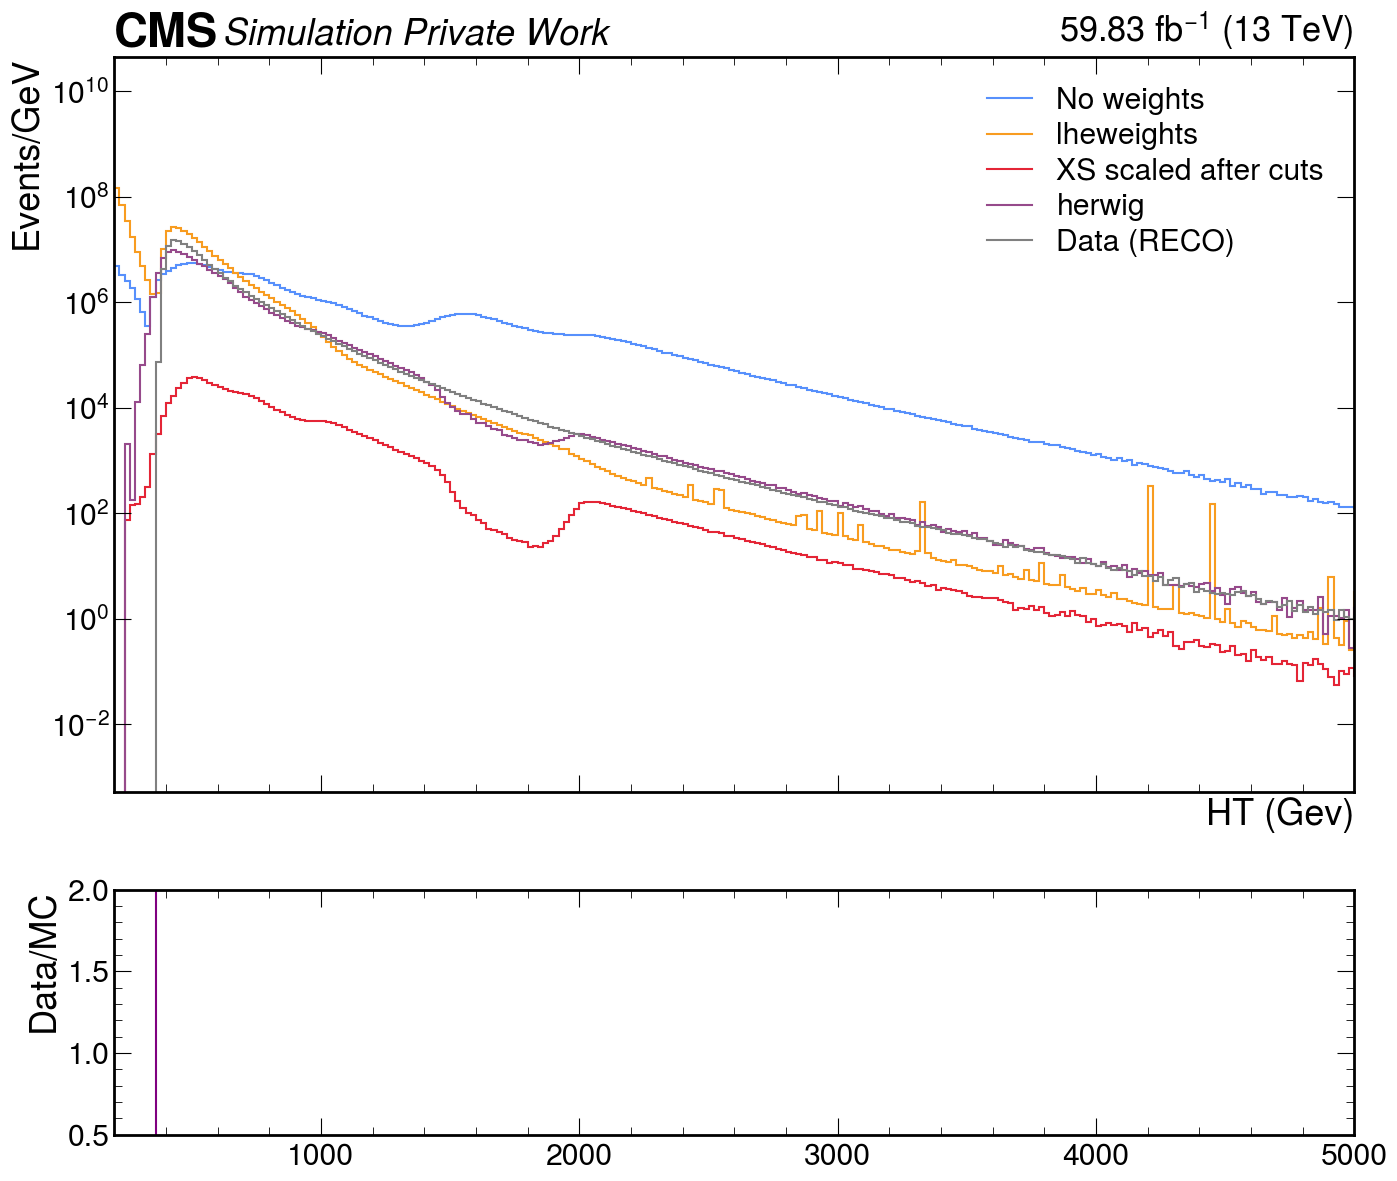

In [65]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(16,14),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
edges = [bin[0] for bin in result_noxs["HT_aftercuts"].project("pt").axes[0]] + [result_noxs["HT_aftercuts"].project('pt').axes[0][-1][1]]
hist = result_noxs['HT_nocuts'].project("pt").values()
hist1 = result_noxs["HT_wXS"][{'syst':'nominal'}].project("pt").values()
# hist2 = result["HT_wXS"][{'syst':'nominal'}].project("pt").values()
hist3 = result["HT_aftercuts"][{'systematic':'nominal'}].project("pt").values()
hist4 = result_herwig["HT_aftercuts"][{'systematic':'nominal'}].project("pt").values()
histdata = result_data["HT_aftercuts"].project("pt").values()
n_data = np.sum(histdata)
# hist1 = hist1*n_data/np.sum(hist1)
# hist = hist*n_data/np.sum(hist)
# hist2 = hist2*n_data/np.sum(hist2)
np.divide(histdata,hist3,
                          out=np.empty(np.array(histdata).shape).fill(np.nan),
                          where=hist3!= 0,)
ratio = histdata/hist3
print(ratio)
ax.set_xlim(200,5000)
ax.set_ylabel("Events/GeV")
rax.set_ylim(0.5,2)
# ax.set_xscale('log')
hep.cms.label("Private Work", com = 13, lumi = 59.83, data = False, loc=0, ax=ax);
ax.set_yscale('log')
hep.histplot(ratio, edges, ax=rax, stack=False, color='purple')
hep.histplot(hist, edges, ax=ax, label = "No weights", stack=False)
hep.histplot(hist1, edges, binwnorm=True, label="lheweights", ax=ax, stack=False)
# hep.histplot(hist2, edges, binwnorm=True, label="XS scaled", ax=ax, stack=False)
hep.histplot(hist3, edges, binwnorm=True, label="XS scaled after cuts", ax=ax, stack=False)
hep.histplot(hist4, edges, binwnorm=True, label="herwig", ax=ax, stack=False)
hep.histplot(histdata, edges, binwnorm=True, label="Data (RECO)", ax=ax, stack=False, color='grey')
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='small')
leg.set_visible(True)
ax.set_xlabel("HT (Gev)")

Hist(
  StrCategory(['QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'FSRUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'ISRUp', 'ISRDown', 'Q2muRDown', 'FSRDown'], growth=True, name='systematic', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([0.00e+00, 2.50e+00, 5.00e+00, 7.50e+00, 1.00e+01, 1.50e+01,
       2.00e+01, 3.00e+01, 4.00e+01, 5.00e+01, 6.00e+01, 7.00e+01,
       8.00e+01, 9.00e+01, 1.00e+02, 1.10e+02, 1.20e+02, 1.30e+02,
       1.40e+02, 1.50e+02, 1.60e+02, 1.70e+02, 1.80e+02, 1.90e+02,
       2.00e+02, 2.50e+02, 3.00e+02, 3.50e+02, 4.00e+02, 4.50e+02,
       5.00e+02, 6.00e+02, 7.00e+02, 8.00e+02, 9.00e+02, 1.00e+03,
       1.10e+03, 1.20e+03, 1.30

ValueError: The axis name systematic could not be found

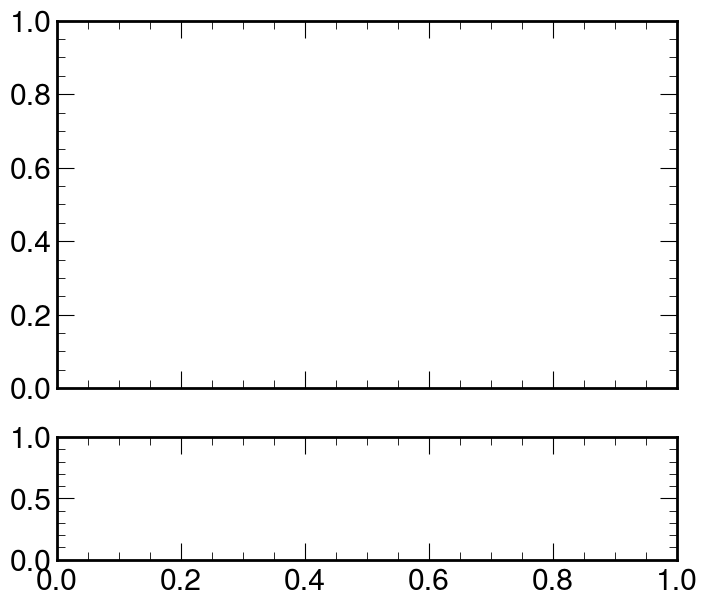

In [60]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
histname = "ptjet_mjet_u_reco"
print(result["ptjet_mjet_u_reco"])
edges = [bin[0] for bin in result[histname].project("mreco").axes[0]] + [result[histname].project('mreco').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data[histname][{'systematic':'nominal'}].project("mreco").axes[0]] + [result[histname].project('mreco').axes[0][-1][1]]
print(edges_data)
hist_data = result_data[histname][{'systematic':'nominal'}].project("mreco").values()
hist_mc = result[histname][{'systematic':'nominal'}].project("mreco").values()
hist_noxs = result_noxs["ptreco_mreco_u][{'systematic':'nominal'}].project("mreco").values()
n_data = np.sum(hist_data)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
# hist_noxs = hist_noxs*n_data/np.sum(hist_noxs)
ratio = hist_data/hist_mc
# ratio1 = hist_data/hist_noxs
ax.set_xlim(0,400)
rax.set_ylim(0,2)
ax.set_yscale('log')
print(len(ratio))
print(len(hist_data))
print(len(hist_mc))
print(len(edges))
print(hist_mc)
hep.cms.label("Private Work", com = 13, lumi = 59.83, data = True, loc=0, ax=ax);
hep.histplot(ratio, edges,ax=rax, stack=False, color='orange')
# hep.histplot(ratio1, edges, ax=rax, stack=False, color='red')
hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False,color='orange')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False,color='blue')
# hep.histplot(hist_noxs, edges, binwnorm=True, label="qcd nxs", ax=ax, stack=False,color='red')
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
ax.set_xlabel("Ungroomed mass (Gev)")

Hist(
  StrCategory(['QCD_pythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'FSRUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'ISRUp', 'ISRDown', 'Q2muRDown', 'FSRDown'], growth=True, name='systematic', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 820, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([0.00e+00, 2.50e+00, 5.00e+00, 7.50e+00, 1.00e+01, 1.50e+01,
       2.00e+01, 3.00e+01, 4.00e+01, 5.00e+01, 6.00e+01, 7.00e+01,
       8.00e+01, 9.00e+01, 1.00e+02, 1.10e+02, 1.20e+02, 1.30e+02,
       1.40e+02, 1.50e+02, 1.60e+02, 1.70e+02, 1.80e+02, 1.90e+02,
       2.00e+02, 2.50e+02, 3.00e+02, 3.50e+02, 4.00e+02, 4.50e+02,
       5.00e+02, 6.00e+02, 7.00e+02, 8.00e+02, 9.00e+02, 1.00e+03,
       1.10e+03, 1.20e+03, 1.30

Text(1, 0, 'Ungroomed mass (Gev)')

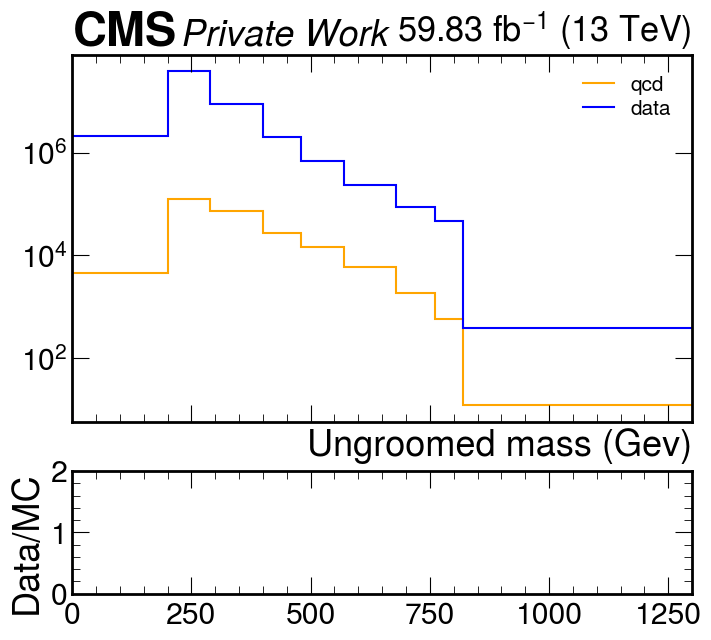

In [61]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
histname = "ptjet_mjet_u_reco"
print(result["ptjet_mjet_u_reco"])
edges = [bin[0] for bin in result[histname].project("ptreco").axes[0]] + [result[histname].project('ptreco').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data[histname][{'systematic':'nominal'}].project("ptreco").axes[0]] + [result[histname].project('ptreco').axes[0][-1][1]]
print(edges_data)
hist_data = result_data[histname][{'systematic':'nominal'}].project("ptreco").values()
hist_mc = result[histname][{'systematic':'nominal'}].project("ptreco").values()
hist_noxs = result_noxs["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").values()
n_data = np.sum(hist_data)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
# hist_noxs = hist_noxs*n_data/np.sum(hist_noxs)
ratio = hist_data/hist_mc
# ratio1 = hist_data/hist_noxs
ax.set_xlim(0,1300)
rax.set_ylim(0,2)
ax.set_yscale('log')
print(len(ratio))
print(len(hist_data))
print(len(hist_mc))
print(len(edges))
print(hist_mc)
hep.cms.label("Private Work", com = 13, lumi = 59.83, data = True, loc=0, ax=ax);
hep.histplot(ratio, edges,ax=rax, stack=False, color='orange')
# hep.histplot(ratio1, edges, ax=rax, stack=False, color='red')
hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False,color='orange')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False,color='blue')
# hep.histplot(hist_noxs, edges, binwnorm=True, label="qcd nxs", ax=ax, stack=False,color='red')
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
ax.set_xlabel("Ungroomed mass (Gev)")

In [ ]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["ptreco_mreco_g"].project("mreco").axes[0]] + [result["ptreco_mreco_g"].project('mreco').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data["ptreco_mreco_g"][{'syst':'nominal'}].project("mreco").axes[0]] + [result["ptreco_mreco_g"].project('mreco').axes[0][-1][1]]
print(edges_data)
hist_data = result_data["ptreco_mreco_g"][{'syst':'nominal'}].project("mreco").values()
hist_mc = result["ptreco_mreco_g"][{'syst':'nominal'}].project("mreco").values()
hist_noxs = result_noxs["ptreco_mreco_g"][{'syst':'nominal'}].project("mreco").values()
n_data = np.sum(hist_data)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
# hist_noxs = hist_noxs*n_data/np.sum(hist_noxs)
ratio = hist_data/hist_mc
# ratio1 = hist_data/hist_noxs
ax.set_xlim(0,400)
rax.set_ylim(0,2)
ax.set_yscale('log')
print(len(ratio))
print(len(hist_data))
print(len(hist_mc))
print(len(edges))
print(hist_mc)
hep.cms.label("Private Work", com = 13, lumi = 59.83, data = True, loc=0, ax=ax);
hep.histplot(ratio, edges,ax=rax, stack=False, color='orange')
# hep.histplot(ratio1, edges, ax=rax, stack=False, color='red')
hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False,color='orange')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False,color='blue')
# hep.histplot(hist_noxs, edges, binwnorm=True, label="qcd nxs", ax=ax, stack=False,color='red')
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
ax.set_xlabel("Groomed mass (Gev)")

Hist(
  StrCategory(['/QCD_HpythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'Q2muRDown'], growth=True, name='syst', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([   0. ,    2.5,    5. ,    7.5,   10. ,   15. ,   20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,   90. ,  100. ,  110. ,
        120. ,  130. ,  140. ,  150. ,  160. ,  170. ,  180. ,  190. ,
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]), name='mreco', label='$m_{RECO}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=6.50625e+10, variance=1.08813e+13) (WeightedSum(value=6.50625e+10, variance=1.0

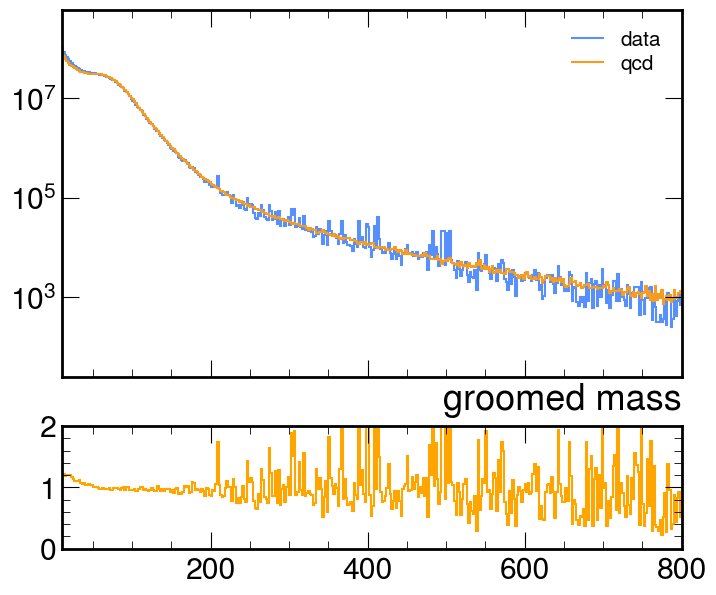

In [11]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["ptreco_mreco_fine_u"].project("mass").axes[0]] + [result["ptreco_mreco_fine_u"].project('mass').axes[0][-1][1]]
edges1 = [bin[0] for bin in result_noxs["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("mass").axes[0]] + [result_noxs["ptreco_mreco_fine_g"].project('mass').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("mass").values()
hist_mc_noxs = result_noxs["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("mass").values()
# hist_mc_noxs1 = result["sdmass_orig"].project("mass").values()
# hist_mc_noxs2 = result["sdmass_ak4corr"].project("mass").values()
hist_mc = result["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("mass").values()
n_data = np.sum(hist_data)
# hist_mc_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
# hist_mc_noxs1 = hist_mc_noxs1*n_data/np.sum(hist_mc_noxs1)
# hist_mc_noxs2 = hist_mc_noxs2*n_data/np.sum(hist_mc_noxs2)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
# ratio = hist_data/hist_mc
ratio1 = hist_data/hist_mc
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
ax.set_xlim(10,800)
rax.set_ylim(0,2)
ax.set_yscale('log')
# hep.histplot(ratio, edges1,ax=rax, color='orange')
ax.set_xlabel("groomed mass")
hep.histplot(ratio1, edges1,ax=rax, color='orange')
hep.histplot(hist_data, edges1, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc, edges, binwnorm=True, label="qcd", ax=ax, stack=False)
# hep.histplot(hist_mc_noxs, edges1, binwnorm=True, label="qcd lhe weights", ax=ax, stack=False)
# hep.histplot(hist_mc_noxs1, edges, binwnorm=True, label="no cuts no mass corr", ax=ax, stack=False)
# hep.histplot(hist_mc_noxs2, edges, binwnorm=True, label="no cuts", ax=ax, stack=False)
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["ptreco_mreco_fine_u"].project("pt").axes[0]] + [result["ptreco_mreco_fine_u"].project('pt').axes[0][-1][1]]
edges1 = [bin[0] for bin in result_noxs["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("pt").axes[0]] + [result_noxs["ptreco_mreco_fine_g"].project('pt').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("pt").values()
hist_mc_noxs = result_noxs["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("pt").values()
hist_mc_noxs1 = result_noxs["sdmass_orig"].project("pt").values()
hist_mc = result["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("pt").values()
n_data = np.sum(hist_data)
# hist_mc_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
# hist_mc_noxs1 = hist_mc_noxs1*n_data/np.sum(hist_mc_noxs1)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
ratio = hist_data/hist_mc
ratio1 = hist_data/hist_mc_noxs
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
# ax.set_xlim(200,1300)
rax.set_ylim(0,2)
rax.set_ylabel("Data/MC")
rax.set_xlabel("Jet Pt (GeV)")
ax.set_ylabel("Pt")
ax.set_yscale('log')
hep.histplot(ratio, edges,ax=rax, color='orange')
hep.histplot(ratio1, edges,ax=rax, color='red')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc, edges, binwnorm=True, label="qcd", ax=ax, stack=False)
hep.histplot(hist_mc_noxs, edges1, binwnorm=True, label="qcd lhe weihgts", ax=ax, stack=False, color='red')
hep.histplot(hist_mc_noxs1, edges1, binwnorm=True, label="qcd no weights", ax=ax, stack=False, color="green")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
edges = [bin[0] for bin in result["ptreco_mreco_fine_u"].project("mass").axes[0]] + [result["ptreco_mreco_fine_u"].project('mass').axes[0][-1][1]]

edges_data = [bin[0] for bin in result_data["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("mass").axes[0]] + [result["ptreco_mreco_fine_u"].project('mass').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("mass").values()
hist_mc_noxs = result_noxs["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("mass").values()
# hist_mc_noxs1 = result["mass_orig"].project("mass").values()
hist_mc = result["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("mass").values()
n_data = np.sum(hist_data)
hist_mc_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
hist_mc_noxs1 = hist_mc_noxs1*n_data/np.sum(hist_mc_noxs1)
hist_mc = hist_mc*n_data/np.sum(hist_mc)
ratio = hist_data/hist_mc
ratio1 = hist_data/hist_mc_noxs
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
ax.set_xlim(0,400)
rax.set_ylim(0,2)
ax.set_yscale('log')
ax.set_xlabel('Ungroomed mass')
hep.histplot(ratio, edges,ax=rax, color='orange')
hep.histplot(ratio1, edges,ax=rax, color='red')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc, edges, binwnorm=True, label="qcd w/ xs", ax=ax, stack=False)
hep.histplot(hist_mc_noxs, edges, binwnorm=True, label="QCD lhe weights", ax=ax, stack=False)
# hep.histplot(hist_mc_noxs1, edges, binwnorm=True, label="QCD no weights", ax=ax, stack=False, color="green")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
print(result.keys())
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["sdmass_orig"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["sdmass_orig"].project("pt").axes[0]] + [result["sdmass_orig"].project('pt').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data["sdmass_orig"].project("pt").axes[0]] + [result["sdmass_orig"].project('pt').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["sdmass_orig"].project("pt").values()
hist_mc_noxs = result_noxs["sdmass_orig"].project("pt").values()
hist_mc = result["sdmass_orig"].project("pt").values()
# n_data = np.sum(hist_data)
# hist_mc_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
ratio = hist_data/hist_mc
ratio1 = hist_data/hist_mc_noxs
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
rax.set_ylim(0,2)

ax.set_yscale('log')
hep.histplot(ratio, edges,ax=rax, color='orange')
hep.histplot(ratio1, edges,ax=rax, color='red')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc, edges, binwnorm=True, label="qcd", ax=ax, stack=False, color="orange")
hep.histplot(hist_mc_noxs, edges, binwnorm=True, label="qcd no xs", ax=ax, stack=False, color="red")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["ptreco_mreco_u"].project("ptreco").axes[0]] + [result["ptreco_mreco_u"].project('ptreco').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").axes[0]] + [result["ptreco_mreco_u"].project('ptreco').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").values()
hist_mc = result["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").values()
hist_mc_noxs = result_noxs["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").values()
n_data = np.sum(hist_data)
hist_mc = hist_mc*n_data/np.sum(hist_mc)
hist_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
ratio = hist_data/hist_mc
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
ax.set_xlim(0,1300)

ax.set_yscale('log')
hep.histplot(ratio, edges,ax=rax)
hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False)
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc_noxs, edges, binwnorm=True, label="qcd no xs", ax=ax, stack=False)
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
mc_hists = []
axVar = "ptreco"
hist_data = result_data["ptreco_mreco_u"].project("ptreco").values()
n_data = np.sum(result_data["ptreco_mreco_u"].project("ptreco").values(),axis=0)
print(n_data)
edges = [bin[0] for bin in result["ptreco_mreco_u"].project("ptreco").axes[0]] + [result["ptreco_mreco_u"].project('ptreco').axes[0][-1][1]]
for i in range(len(results)):
    result = results[i]
    hist = result["ptreco_mreco_u"].project("ptreco").values()
    mc_hists.append(hist)
n_mc = np.sum(np.sum(mc_hists, axis=0))
mc_stack = np.sum(mc_hists, axis=0)*n_data/n_mc

fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
for i in range(len(results)):
    result = results[i]
    hist = result["ptreco_mreco_u"].project("ptreco")*n_data/n_mc
    hep.histplot(hist, binwnorm=True, label="MC "+result_str[i], ax=ax, stack=True)
    ax.set_xlim(0,1300)
    ax.set_yscale('log')
ratio = hist_data/mc_stack
hep.histplot(ratio, edges, ax=rax, stack=False)
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

mc_hists = []
edges = [bin[0] for bin in result["ptreco_mreco_g"].project("mreco").axes[0]] + [result["ptreco_mreco_g"].project('mreco').axes[0][-1][1]]
for i in range(len(results)):
    result = results[i]
    hist = result["ptreco_mreco_g"].project("mreco").values()
    mc_hists.append(hist)
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
for i in range(len(results)):
    result = results[i]
    hist = result["ptreco_mreco_g"].project("mreco")
    hep.histplot(hist, binwnorm=True, label="MC "+result_str[i], ax=ax, stack = True)
    ax.set_xlim(0,1300)
    ax.set_yscale('log')

hist = result_data["ptreco_mreco_g"].project("mreco")
hep.histplot(hist, binwnorm=True, label="data", ax=ax, stack=False)
# mc_stack = np.sum(mc_hists, axis=0)
# ratio = hist.values()/mc_stack
# hep.histplot(ratio, edges, binwnorm=True, ax=rax, stack=False)

leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
print(result["MET_over_sumET_pt_reco"])
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
for i in range(len(results)):
    result = results[i]
    hist = result["MET_pt_reco"].project("pt")
    hep.histplot(hist, binwnorm=True, label="MC "+result_str[i], ax=ax, stack=True)
    ax.set_xlim(0,1300)
    ax.set_yscale('log')
ax.set_xlabel("")
rax.set_xlabel("MET (GeV)")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
for i in range(len(results)):
    result = results[i]
    hist = result["MET_over_sumET_pt_reco"].project("frac")
    hep.histplot(hist, binwnorm=True, label="MC "+result_str[i], ax=ax, stack = True)
    ax.set_yscale('log')
ax.set_xlabel("")
rax.set_xlabel("MET/Sum_ET")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)